# Pengolahan Citra Digital
**Metadata dan Representasi Citra Digital**




In [16]:
import os
import json
import numpy as np
from PIL import Image, ExifTags
from PIL.ExifTags import IFD, GPSTAGS
import matplotlib.pyplot as plt

# 1. Open Image
img_path = os.path.join("images", "DSC08278.JPG")
img = Image.open(img_path)
img_format = img.format

# Basic resolution and image size
width, height = img.size
total_pixels = width * height
file_size_mb = os.path.getsize(img_path) / (1024 * 1024)

print(f"Image successfully loaded : {img_path}")
print(f"Format and File Size      : {img_format} ({file_size_mb:.2f} MB)")
print(f"Image Resolution          : {width} x {height} pixels ({total_pixels / 1e6:.1f} Megapixels)")

Image successfully loaded : images\DSC08278.JPG
Format and File Size      : MPO (4.81 MB)
Image Resolution          : 6000 x 4000 pixels (24.0 Megapixels)


## 1. Metadata Photo (EXIF)


In [17]:

exif = img.getexif()

# 1. EXIF UTAMA (Info Berkas & Metadata Dasar IFD0)
exif_utama = {
    "Nama_File": os.path.basename(img_path),
    "Format_File": img.format,
    "Mode_Warna": img.mode,
    "Resolusi": f"{img.width} x {img.height} piksel",
    "Ukuran_File": f"{os.path.getsize(img_path) / (1024 * 1024):.2f} MB",
}

for tag_id, val in exif.items():
  nama_tag = ExifTags.TAGS.get(tag_id, str(tag_id))
  exif_utama[nama_tag] = val

# 2. SUB-EXIF (Pengaturan Teknis Kamera, Lensa, dan GPS)
sub_exif = {}

sub_ifd_list = [
    (IFD.Exif, ExifTags.TAGS),
    (IFD.IFD1, ExifTags.TAGS),
    (IFD.Interop, ExifTags.TAGS),
]

for ifd_code, kamus_tag in sub_ifd_list:
  sub = exif.get_ifd(ifd_code)
  for tag_id, val in sub.items():
    nama_tag = kamus_tag.get(tag_id, str(tag_id))
    sub_exif[nama_tag] = val

gps_data = {}
gps_sub = exif.get_ifd(IFD.GPSInfo)
for tag_id, val in gps_sub.items():
  gps_data[GPSTAGS.get(tag_id, str(tag_id))] = val

sub_exif["GPSInfo"] = gps_data if gps_data else None


hasil_exif = {"exif_utama": exif_utama, "sub_exif": sub_exif}

# 4. Output JSON
print(json.dumps(hasil_exif, indent=4, default=str))


{
    "exif_utama": {
        "Nama_File": "DSC08278.JPG",
        "Format_File": "MPO",
        "Mode_Warna": "RGB",
        "Resolusi": "6000 x 4000 piksel",
        "Ukuran_File": "4.81 MB",
        "PrintImageMatching": "b'PrintIM\\x000300\\x00\\x00\\x03\\x00\\x02\\x00\\x01\\x00\\x00\\x00\\x03\\x00\"\\x00\\x00\\x00\\x01\\x01\\x00\\x00\\x00\\x00\\t\\x11\\x00\\x00\\x10\\'\\x00\\x00\\x0b\\x0f\\x00\\x00\\x10\\'\\x00\\x00\\x97\\x05\\x00\\x00\\x10\\'\\x00\\x00\\xb0\\x08\\x00\\x00\\x10\\'\\x00\\x00\\x01\\x1c\\x00\\x00\\x10\\'\\x00\\x00^\\x02\\x00\\x00\\x10\\'\\x00\\x00\\x8b\\x00\\x00\\x00\\x10\\'\\x00\\x00\\xcb\\x03\\x00\\x00\\x10\\'\\x00\\x00\\xe5\\x1b\\x00\\x00\\x10\\'\\x00\\x00'",
        "ResolutionUnit": 2,
        "ExifOffset": 364,
        "ImageDescription": "                               ",
        "Make": "SONY",
        "Model": "ILCE-6400",
        "Software": "ILCE-6400 v2.00",
        "Orientation": 8,
        "DateTime": "2025:04:12 13:07:13",
        "YCbCrPositioning": 2

In [18]:

gps_val = sub_exif.get("GPSInfo")
gps_str = str(gps_val) if gps_val is not None else "None"

metadata = f"""
{"=" * 40}
          PHOTO METADATA
{"=" * 40}
File        : {exif_utama.get("Nama_File")}
Format      : {exif_utama.get("Format_File")}
Size        : {exif_utama.get("Ukuran_File")}
Resolution  : {exif_utama.get("Resolusi")}
Pixels      : {total_pixels:,} ({total_pixels / 1e6:.1f} MP)
Camera      : {exif_utama.get("Make", "")} {exif_utama.get("Model", "")}
Lens        : {sub_exif.get("LensModel", "-")}
Date        : {sub_exif.get("DateTimeOriginal", "-")}
ISO         : {sub_exif.get("ISOSpeedRatings", "-")}
Aperture    : f/{sub_exif.get("FNumber", "-")}
Shutter     : {sub_exif.get("ExposureTime", "-")} s
Focal Length: {sub_exif.get("FocalLength", "-")} mm
GPS         : {sub_exif.get("GPSInfo")}
{"=" * 40}
"""

print(metadata)



          PHOTO METADATA
File        : DSC08278.JPG
Format      : MPO
Size        : 4.81 MB
Resolution  : 6000 x 4000 piksel
Pixels      : 24,000,000 (24.0 MP)
Camera      : SONY ILCE-6400
Lens        : 30mm F1.4 DC DN | Contemporary 016
Date        : 2025:04:12 13:07:13
ISO         : 100
Aperture    : f/1.8
Shutter     : 0.003125 s
Focal Length: 30.0 mm
GPS         : None



## 2. Representasi Matriks Citra Digital (NumPy Array)
### Mengonversi citra berwarna menjadi tensor 3D untuk menginspeksi nilai piksel asli RGB.

In [19]:
# Konversi citra ke NumPy array
arr = np.array(img)

print("=" * 45)
print("       DATA MATRIKS PIKSEL (NUMPY)")
print("=" * 45)
print("Bentuk Matriks (H, W, C) :", arr.shape)
print("Tipe Data                :", arr.dtype)
print("Total Nilai Angka        :", f"{arr.size:,}")

center_y = height // 2
center_x = width // 2
print(
    f"\nNilai piksel di titik tengah ({center_y}, {center_x}) [R, G, B]:",
    arr[center_y, center_x],
)

print(
    f"\nPotongan matriks 5x5 Piksel [R, G, B] di titik tengah (y={center_y},"
    f" x={center_x}):"
)
sub_rgb = arr[center_y - 2 : center_y + 3, center_x - 2 : center_x + 3]
for i in range(5):
  baris_str = [f"[{r},{g},{b}]" for r, g, b in sub_rgb[i]]
  print(" ".join(baris_str))


       DATA MATRIKS PIKSEL (NUMPY)
Bentuk Matriks (H, W, C) : (4000, 6000, 3)
Tipe Data                : uint8
Total Nilai Angka        : 72,000,000

Nilai piksel di titik tengah (2000, 3000) [R, G, B]: [248 197   0]

Potongan matriks 5x5 Piksel [R, G, B] di titik tengah (y=2000, x=3000):
[249,184,0] [250,185,0] [249,184,0] [249,184,0] [247,185,0]
[251,186,0] [251,186,0] [252,190,0] [251,189,0] [250,188,0]
[251,195,0] [251,195,0] [248,197,0] [249,198,0] [247,197,0]
[251,194,0] [248,191,0] [246,193,0] [249,196,0] [251,199,0]
[250,188,0] [248,186,0] [248,188,0] [248,187,0] [245,189,0]


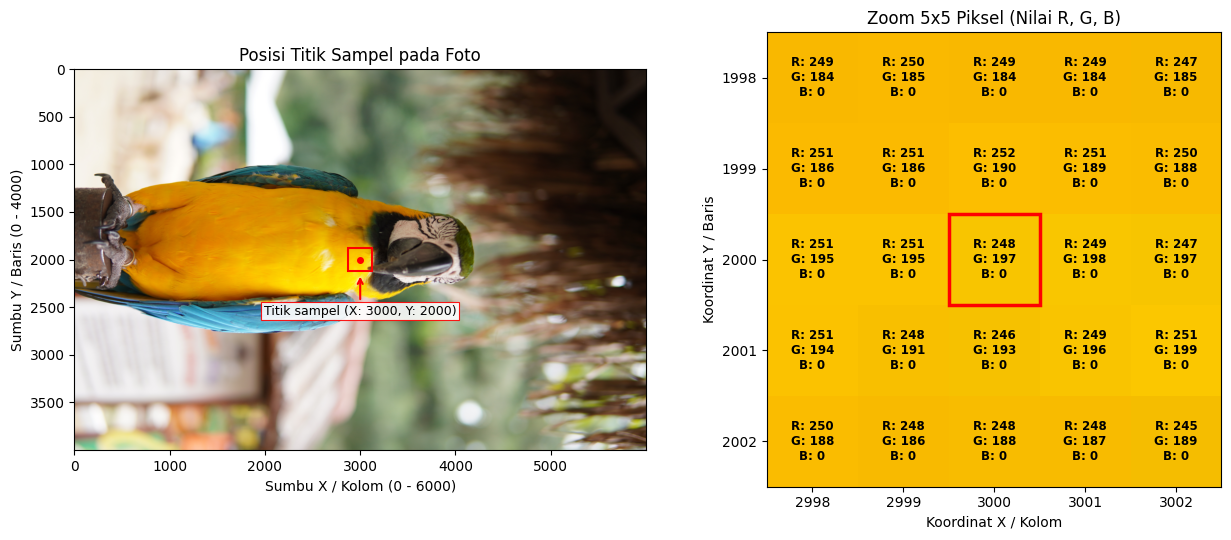

In [20]:
arr = np.array(Image.open(img_path))
cy, cx = arr.shape[0] // 2, arr.shape[1] // 2  # baris 2000, kolom 3000

# potongan 5x5 piksel RGB di titik tengah
sub_rgb = arr[cy - 2 : cy + 3, cx - 2 : cx + 3]

# kanvas 2 kolom
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

ax1.imshow(arr)

ukuran_kotak = 250
kotak = plt.Rectangle(
    (cx - ukuran_kotak // 2, cy - ukuran_kotak // 2),
    ukuran_kotak,
    ukuran_kotak,
    edgecolor="red",
    facecolor="none",
    linewidth=1.5,
)
ax1.add_patch(kotak)

# titik merah di pusat
ax1.plot(cx, cy, "ro", markersize=4)

jarak_gap = 25

ax1.annotate(
    f"Titik sampel (X: {cx}, Y: {cy})",
    xy=(
        cx,
        cy + ukuran_kotak // 2 + jarak_gap,
    ), 
    xytext=(
        cx,
        cy + ukuran_kotak // 2 + 350,
    ), 
    ha="center",
    va="top",
    fontsize=9,
    fontweight="medium",
    color="black",
    bbox=dict(
        boxstyle="square,pad=0.2",
        facecolor="white",
        alpha=0.9,
        edgecolor="red",
        linewidth=0.8,
    ),
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=1.5,
    ),
)


ax1.set_title("Posisi Titik Sampel pada Foto", fontweight="medium")
ax1.set_xlabel("Sumbu X / Kolom (0 - 6000)")
ax1.set_ylabel("Sumbu Y / Baris (0 - 4000)")

ax2.imshow(sub_rgb)

# nilai R, G, B di dalam tiap kotak
for i in range(5):
  for j in range(5):
    r, g, b = sub_rgb[i, j]
    ax2.text(
        j,
        i,
        f"R: {r}\nG: {g}\nB: {b}",
        ha="center",
        va="center",
        color="black",
        fontweight="bold",
        fontsize=8.5,
    )

kotak_merah_tengah = plt.Rectangle(
    (1.5, 1.5), 1, 1, fill=False, edgecolor="red", linewidth=2.5
)
ax2.add_patch(kotak_merah_tengah)

ax2.set_title("Zoom 5x5 Piksel (Nilai R, G, B)", fontweight="medium")
ax2.set_xticks(range(5), [cx - 2, cx - 1, cx, cx + 1, cx + 2])
ax2.set_yticks(range(5), [cy - 2, cy - 1, cy, cy + 1, cy + 2])
ax2.set_xlabel("Koordinat X / Kolom")
ax2.set_ylabel("Koordinat Y / Baris")

plt.tight_layout()
plt.show()


## 3. Analisis Kanal Warna (RGB)
Statistik nilai piksel untuk masing-masing kanal R, G, dan B.

In [21]:
# Pisahkan ketiga kanal warna
r = arr[:, :, 0]
g = arr[:, :, 1]
b = arr[:, :, 2]

print("=" * 45)
print("         STATISTIK KANAL WARNA")
print("=" * 45)
print(f"Red   -> Min: {r.min()}, Max: {r.max()}, Mean: {r.mean():.2f}")
print(f"Green -> Min: {g.min()}, Max: {g.max()}, Mean: {g.mean():.2f}")
print(f"Blue  -> Min: {b.min()}, Max: {b.max()}, Mean: {b.mean():.2f}")
print("=" * 45)


         STATISTIK KANAL WARNA
Red   -> Min: 0, Max: 255, Mean: 148.06
Green -> Min: 0, Max: 255, Mean: 135.99
Blue  -> Min: 0, Max: 255, Mean: 101.82


## 4. Visualisasi Citra & Histogram
Menampilkan visual kanal R, G, B dan grafik histogram nilai pikselnya.


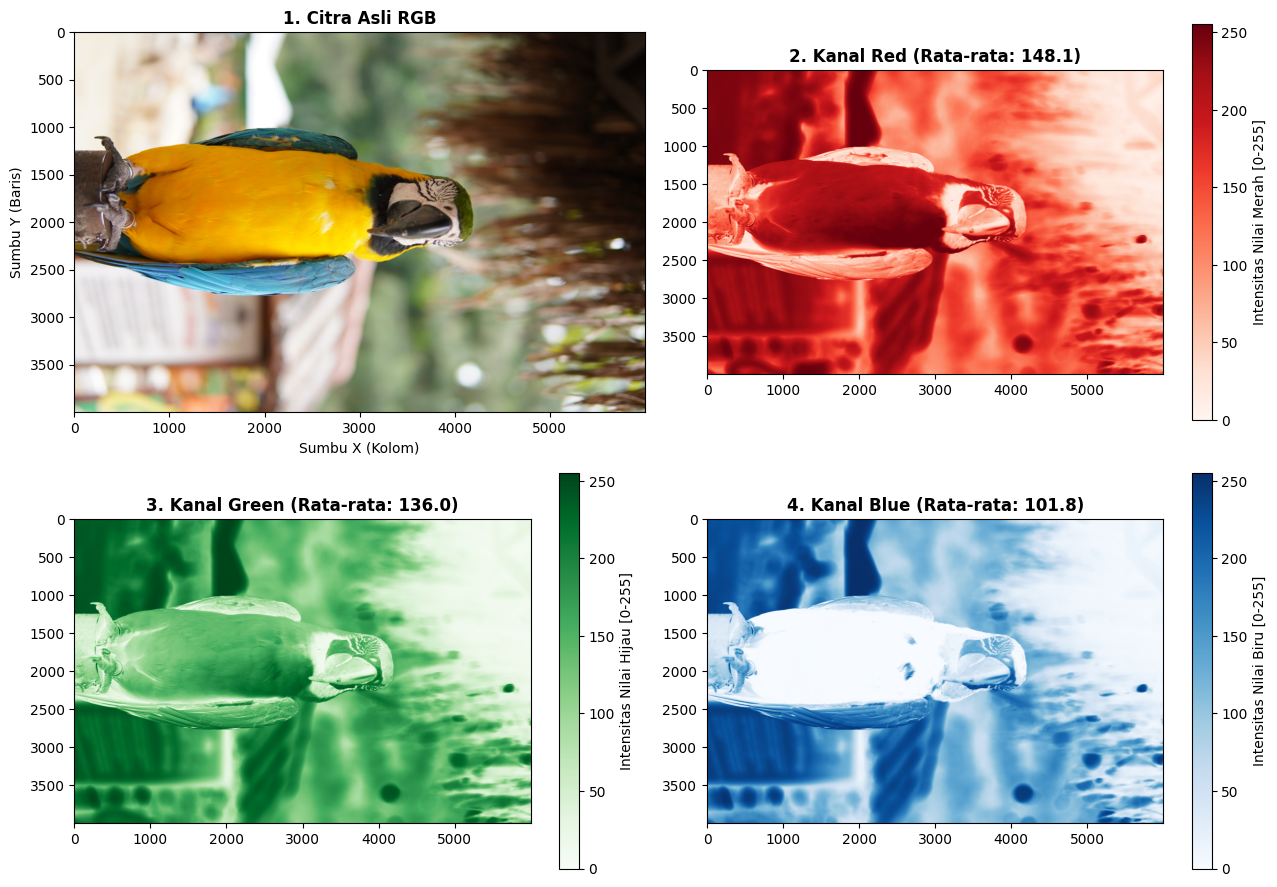

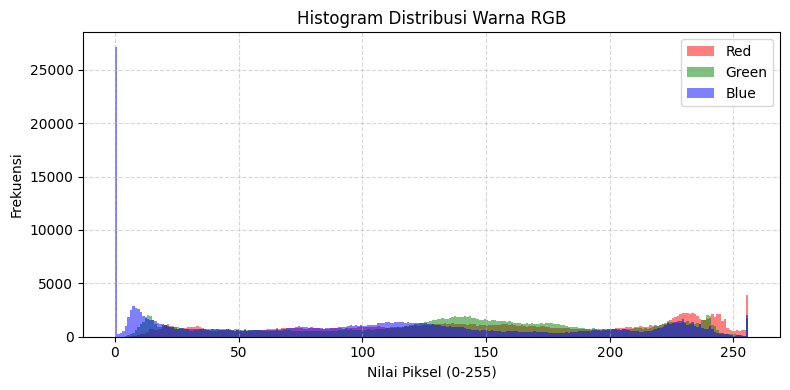

In [22]:
# 1. Visualisasi per kanal dengan garis koordinat & skala warna (colorbar)
plt.figure(figsize=(13, 9))

# Citra Asli
plt.subplot(2, 2, 1)
plt.imshow(arr)
plt.title("1. Citra Asli RGB", fontweight="bold")
plt.xlabel("Sumbu X (Kolom)")
plt.ylabel("Sumbu Y (Baris)")

# Kanal Merah
plt.subplot(2, 2, 2)
im_r = plt.imshow(r, cmap="Reds")
plt.title(f"2. Kanal Red (Rata-rata: {r.mean():.1f})", fontweight="bold")
plt.colorbar(im_r, label="Intensitas Nilai Merah [0-255]")

# Kanal Hijau
plt.subplot(2, 2, 3)
im_g = plt.imshow(g, cmap="Greens")
plt.title(f"3. Kanal Green (Rata-rata: {g.mean():.1f})", fontweight="bold")
plt.colorbar(im_g, label="Intensitas Nilai Hijau [0-255]")

# Kanal Biru
plt.subplot(2, 2, 4)
im_b = plt.imshow(b, cmap="Blues")
plt.title(f"4. Kanal Blue (Rata-rata: {b.mean():.1f})", fontweight="bold")
plt.colorbar(im_b, label="Intensitas Nilai Biru [0-255]")

plt.tight_layout()
plt.show()

# 2. Histogram distribusi warna
plt.figure(figsize=(8, 4))
plt.title("Histogram Distribusi Warna RGB")
plt.hist(r[::10, ::10].ravel(), bins=256, range=(0, 256), color="red", alpha=0.5, label="Red")
plt.hist(g[::10, ::10].ravel(), bins=256, range=(0, 256), color="green", alpha=0.5, label="Green")
plt.hist(b[::10, ::10].ravel(), bins=256, range=(0, 256), color="blue", alpha=0.5, label="Blue")
plt.xlabel("Nilai Piksel (0-255)")
plt.ylabel("Frekuensi")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
